In [ ]:
import numpy as np 
import pandas as pd

import os
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
all_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/all"
all_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/all"
all_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/all"

hem_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/hem"
hem_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/hem"
hem_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/hem"

In [3]:
def get_path_image(folder):
    image_paths = []
    image_fnames = os.listdir(folder) 
    for img_id in range(len(image_fnames)):
        img = os.path.join(folder,image_fnames[img_id])
        image_paths.append(img)
    
    return image_paths

In [4]:
img_data = []

for i in [all_0,all_1,all_2,hem_0,hem_1,hem_2]:
    paths = get_path_image(i)
    img_data.extend(paths)
print(len(img_data))

10661


In [5]:
data = {"img_data":img_data,
        "labels":[np.nan for x in range(len(img_data))]}

data = pd.DataFrame(data) 

In [6]:
data["labels"][0:7272] = 1 # ALL
data["labels"][7272:10661] = 0 # HEM

C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_31084\2481703241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][0:7272] = 1 # ALL
C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_31084\2481703241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][7272:10661] = 0 # HEM


In [7]:
data["labels"] = data["labels"].astype("int64")

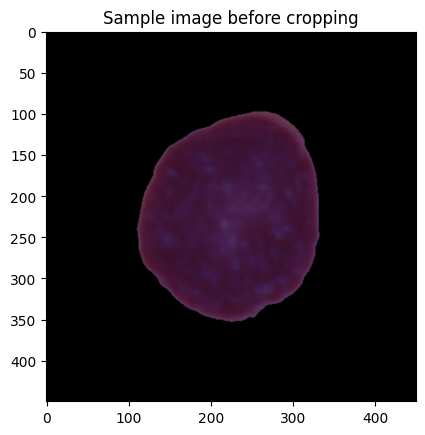

In [8]:
image = cv.imread(data["img_data"][1000])
plt.imshow(image)
plt.title("Sample image before cropping")
plt.show()

In [9]:
img_list = []
for i in range(len(img_data)):
    image = cv.imread(data["img_data"][i])
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)[1]

    result = cv.bitwise_and(image, image, mask=thresh)
    result[thresh==0] = [255,255,255] 
    (x, y, z_) = np.where(result > 0)
    mnx = (np.min(x))
    mxx = (np.max(x))
    mny = (np.min(y))
    mxy = (np.max(y))
    crop_img = image[mnx:mxx,mny:mxy,:]
    crop_img_r = cv.resize(crop_img, (224,224))
    img_list.append(crop_img_r)

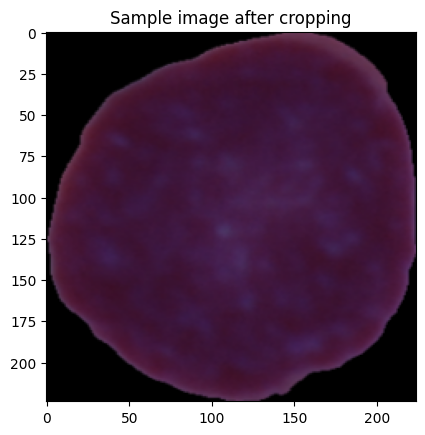

In [10]:
plt.imshow(img_list[1000])
plt.title("Sample image after cropping")
plt.show()

In [11]:
from tensorflow.keras.applications import ResNet50, ResNet101
from keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input

In [12]:
def feature_extract(model):
    if model == "VGG19": model = VGG19(weights='imagenet',include_top=False, pooling="avg")
    elif model == "ResNet50": model = ResNet50(weights='imagenet',include_top=False,pooling="avg")
    elif model == "ResNet101": model = ResNet101(weights='imagenet',include_top=False,pooling="avg")
    return model

In [13]:
model = feature_extract("ResNet50") # or "VGG19", "ResNet101"

In [14]:
features_list = []
for i in range(len(img_list)):
            
    image = img_list[i].reshape(-1, 224, 224, 3) 
    image = preprocess_input(image)
    
    """
    # Reshaping when VGG19 model is selected
    features = model.predict(image).reshape(512,)
    """

    #Reshaping  when ResNet50 or ResNet101 model is selected
    features = model.predict(image).reshape(2048,)
    
    features_list.append(features)

1/1 [==============================] - 0s 329ms/step


In [15]:
features_df = pd.DataFrame(features_list)

In [16]:
features_df["labels"] = data["labels"]

In [17]:
x = features_df.drop(['labels'], axis = 1)
y = features_df.loc[:,"labels"].values

In [18]:
x

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,5.253783,0.042580,0.051578,0.008029,0.057129,0.004375,0.227441,0.003590,0.005153,0.012571,...,0.561743,0.071850,0.011782,1.103318,0.290165,0.000000,0.491152,0.112431,0.000000,0.310525
1,8.079423,0.011574,0.053684,0.186905,0.000000,0.000000,0.042724,0.000000,0.574390,0.006339,...,0.209751,0.000000,0.000000,1.683905,0.019044,0.000000,0.020532,0.196671,0.081518,0.548087
2,6.266923,0.219213,0.018837,0.008474,0.000000,0.000000,0.224284,0.000000,0.000000,0.012756,...,0.137901,0.000000,0.000000,0.857915,0.159714,0.044442,0.702736,0.286233,0.070878,0.547750
3,6.486918,0.000000,0.020409,0.164188,0.000000,0.039742,0.098523,0.000000,0.136671,0.093839,...,0.383021,0.041494,0.000000,2.700690,0.249594,0.000000,0.152288,0.462613,0.330928,0.708187
4,5.148223,0.060939,0.000000,0.106593,0.000000,0.036498,0.074916,0.095883,0.034331,0.008917,...,0.175660,0.030387,0.190983,0.357074,0.000000,0.015142,0.291253,0.187770,0.045915,0.046781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10656,5.135459,0.023519,0.000000,0.013403,0.095962,0.044262,0.067926,0.006756,0.088878,0.000000,...,0.048080,0.036390,0.021044,0.119651,0.045240,0.000000,0.611429,0.220862,0.202260,1.137161
10657,5.458828,0.028126,0.000000,0.173168,0.000000,0.006622,0.014663,0.024785,0.046513,0.125333,...,0.638946,0.064940,0.215364,0.566119,0.000000,0.000000,0.363782,0.380672,1.268512,0.600716
10658,5.933909,0.000000,0.000000,0.069616,0.000000,0.110708,0.000000,0.000000,0.008634,0.000000,...,0.152811,0.000000,0.011421,0.638716,0.095322,0.000000,0.569343,0.919506,0.474505,0.909486
10659,5.647941,0.059169,0.000000,0.116159,0.007541,0.000000,0.112060,0.000000,0.081253,0.293994,...,1.008240,0.030306,0.088561,0.514058,0.000000,0.000000,0.012645,0.703623,0.492333,1.778769


In [19]:
print(f"Number of features before feature selection: {x.shape[1]}")

Number of features before feature selection: 2048


In [20]:

y

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x_ = scaler.transform(x)

In [22]:
x_ = pd.DataFrame(x_)

In [23]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

def anova_fs():
    
    selector = SelectKBest(f_classif, k=500) # k is number of features
    selector.fit(x_, y)

    cols = selector.get_support(indices=True)
    anova_x = x_[cols]
    return anova_x

In [24]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

def RFE_fs():
    rfe_selector = RFE(estimator=RandomForestClassifier())
    rfe_selector.fit(x_, y)
    
    rfe_support = rfe_selector.get_support()
    rfe_feature = x_.loc[:,rfe_support].columns.tolist()
    
    rfe_x = x_[rfe_feature]
    return rfe_x

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

def rf_fs():
    embeded_rf_selector = SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=5), threshold='1.25*median')
    embeded_rf_selector.fit(x, y)
    
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = x.loc[:,embeded_rf_support].columns.tolist()
    
    rf_x = x[embeded_rf_feature]
    return rf_x

In [26]:
fs_x = rf_fs() # feature selection methods "anova_fs", "RFE_fs"

In [27]:
print(f"Number of features after feature selection: {fs_x.shape[1]}")

Number of features after feature selection: 630


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(fs_x, y, test_size = 0.2, random_state = 42)

In [29]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score,precision_score,recall_score,accuracy_score
from sklearn.model_selection import GridSearchCV

KNN

In [31]:
neig = np.arange(1, 25)
train_accuracy = []
test_accuracy = []

for i, k in enumerate(neig):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    prediction_ = knn.predict(x_test)
    train_accuracy.append(knn.score(x_train, y_train))
    test_accuracy.append(knn.score(x_test, y_test))
    
print("Best accuracy is {} with K = {}".format(np.max(test_accuracy),1+test_accuracy.index(np.max(test_accuracy))))

Best accuracy is 0.8288795124238162 with K = 9


In [32]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(x_train,y_train)
predicted = knn.predict(x_test)
score = knn.score(x_test, y_test)
knn_score_ = np.mean(score)

print('Accuracy : %.3f' % (knn_score_))

Accuracy : 0.827


In [33]:
p=precision_score(y_test, predicted) 
print('Precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('Recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('F1-score: %.3f' % (f1))

f1_w=f1_score(y_test, predicted, average='weighted') 
print('Weighted f1-score: %.3f' % (f1_w))

Precision : 0.828
Recall : 0.943
F1-score: 0.881
Weighted f1-score: 0.817


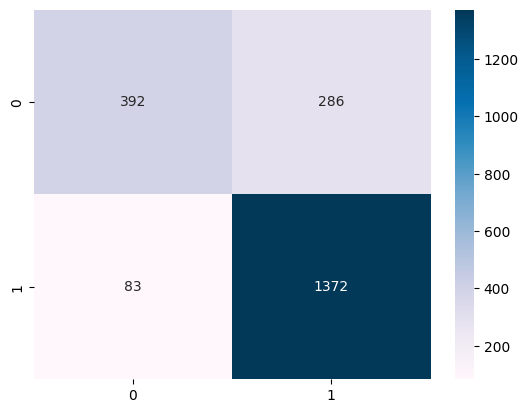

In [34]:


cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()


In [30]:
def plot_roc_cur(fper, tper):  
    plt.plot(fper, tper, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

In [ ]:
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, roc_auc_score, cohen_kappa_score, roc_curve, classification_report
def run_model(svm_clf, x_train, y_train, x_test, y_test, verbose=True):
    t0=time.time()
    if verbose == False:
        svm_clf.fit(x_train,y_train, verbose=0)
    else:
        svm_clf.fit(x_train,y_train)
    y_pred = svm_clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred) 
    coh_kap = cohen_kappa_score(y_test, y_pred)
    time_taken = time.time()-t0
    print("Accuracy = {}".format(accuracy))
    print("ROC Area under Curve = {}".format(roc_auc))
    print("Cohen's Kappa = {}".format(coh_kap))
    print("Time taken = {}".format(time_taken))
    print(classification_report(y_test,y_pred,digits=5))
    
    probs = svm_clf.predict_proba(x_test)  
    probs = probs[:, 1]  
    fper, tper, thresholds = roc_curve(y_test, probs) 
    plot_roc_cur(fper, tper)
    
    ConfusionMatrixDisplay.from_estimator(svm_clf, x_test, y_test)
    
    return svm_clf, accuracy, roc_auc, coh_kap, time_taken

XGBOOST

Accuracy = 0.8720112517580872
ROC Area under Curve = 0.8215141562509504
Cohen's Kappa = 0.6854068982507209
Time taken = 111.54339909553528
              precision    recall  f1-score   support

           0    0.88868   0.68289   0.77231       678
           1    0.86663   0.96014   0.91099      1455

    accuracy                        0.87201      2133
   macro avg    0.87765   0.82151   0.84165      2133
weighted avg    0.87363   0.87201   0.86691      2133



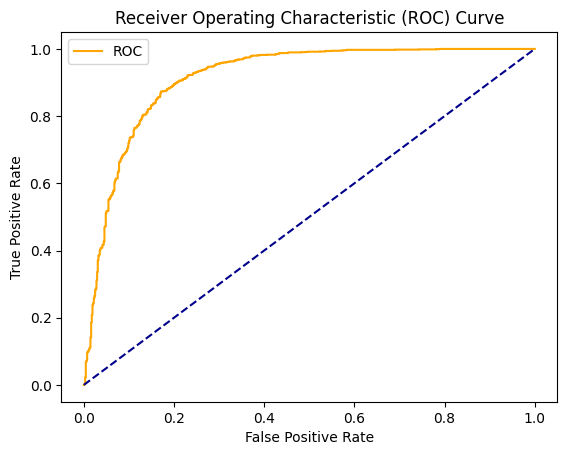

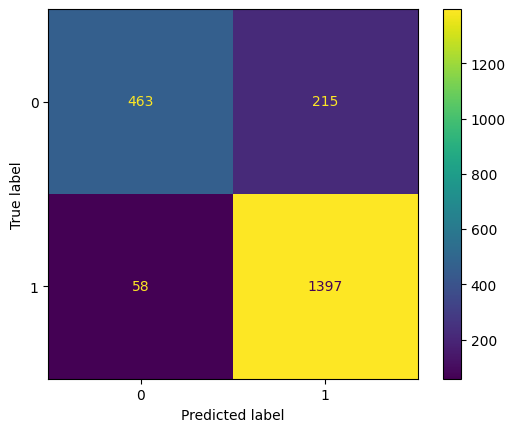

In [38]:
# XGBoost
import xgboost as xgb
params_xgb ={'n_estimators': 500,
            'max_depth': 16}

model_xgb = xgb.XGBClassifier(**params_xgb)
model_xgb, accuracy_xgb, roc_auc_xgb, coh_kap_xgb, tt_xgb = run_model(model_xgb, x_train, y_train, x_test, y_test)

SVM

In [33]:

param_grid_svm = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf', 'poly']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, cv=5)
SVM_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly']})

In [34]:
print(SVM_grid.best_params_)
 
print(SVM_grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


In [35]:
svm_clf = svm.SVC(C=10, gamma=0.005 ,kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.902


In [41]:
#param_grid_svm
#model_xgb = xgb.XGBClassifier(**params_xgb)
svm_clf, accuracy_svm_clf, roc_auc_svm_clf, coh_kap_svm_clf, tt_svm_clf = run_model(svm_clf, x_train, y_train, x_test, y_test)

Accuracy = 0.9020159399906236
ROC Area under Curve = 0.8730438220357023
Cohen's Kappa = 0.7675492866092783
Time taken = 45.754018783569336
              precision    recall  f1-score   support

           0    0.88633   0.79351   0.83735       678
           1    0.90826   0.95258   0.92989      1455

    accuracy                        0.90202      2133
   macro avg    0.89729   0.87304   0.88362      2133
weighted avg    0.90129   0.90202   0.90048      2133



AttributeError: predict_proba is not available when probability=False

RF

In [42]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
#Number of trees in random forest
n_estimators=[int(x) for x in np.linspace(start=200,stop=2000,num=10)]
#Number of features to consider at every split
max_features=['auto','sqrt','log2']
#Maximum number of levels in tree
max_depth=[int(x) for x in np.linspace(10,1000,10)]
#Minimum number of samples required to split a node
min_samples_split=[1,3,4,5,7,9]
#Minimum number of samples required at each leaf node
min_samples_leaf=[1,2,4,6,8]
#create the random grid
random_grid={'n_estimators':n_estimators,
             'max_features':max_features,
             'max_depth':max_depth,
             'min_samples_split':min_samples_split,
             'min_samples_leaf':min_samples_leaf,
             'criterion':['entropy','gini']}
print(random_grid)
             

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 120, 230, 340, 450, 560, 670, 780, 890, 1000], 'min_samples_split': [1, 3, 4, 5, 7, 9], 'min_samples_leaf': [1, 2, 4, 6, 8], 'criterion': ['entropy', 'gini']}


In [43]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
rf=RandomForestClassifier()
rf_randomcv=RandomizedSearchCV(estimator=rf,param_distributions=random_grid,n_iter=100,cv=3,verbose=2,random_state=42,n_jobs=-1)
rf_randomcv.fit(x_train,y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
144 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_paramete

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'criterion': ['entropy', 'gini'],
                                        'max_depth': [10, 120, 230, 340, 450,
                                                      560, 670, 780, 890,
                                                      1000],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6, 8],
                                        'min_samples_split': [1, 3, 4, 5, 7, 9],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [44]:
rf_randomcv.best_estimator_

RandomForestClassifier(max_depth=1000, min_samples_split=3, n_estimators=600)

In [45]:
model_rf=rf_randomcv.best_estimator_

In [46]:
y_pred=model_rf.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print("Accuracy Score {}".format(accuracy_score(y_test,y_pred)))
print("Classification report: {}".format(classification_report(y_test,y_pred)))

[[ 407  271]
 [  73 1382]]
Accuracy Score 0.8387248007501172
Classification report:               precision    recall  f1-score   support

           0       0.85      0.60      0.70       678
           1       0.84      0.95      0.89      1455

    accuracy                           0.84      2133
   macro avg       0.84      0.78      0.80      2133
weighted avg       0.84      0.84      0.83      2133



Accuracy = 0.8401312705110173
ROC Area under Curve = 0.7768801508378189
Cohen's Kappa = 0.6003359504942825
Time taken = 476.0382556915283
              precision    recall  f1-score   support

           0    0.85031   0.60324   0.70578       678
           1    0.83717   0.95052   0.89025      1455

    accuracy                        0.84013      2133
   macro avg    0.84374   0.77688   0.79801      2133
weighted avg    0.84135   0.84013   0.83161      2133



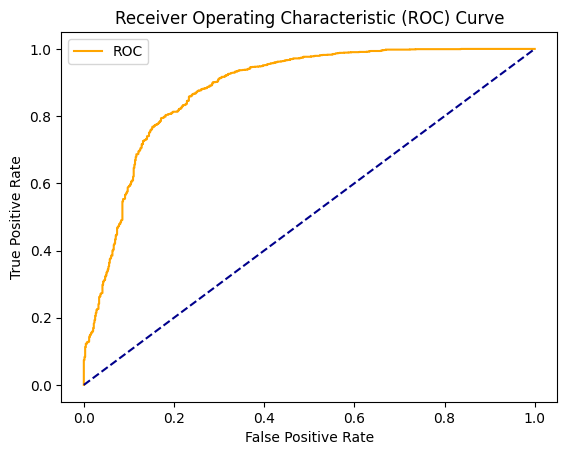

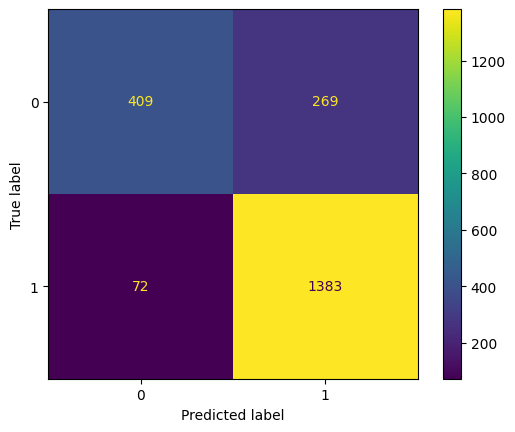

In [47]:
model_rf, accuracy_rf, roc_auc_rf, coh_kap_rf, tt_rf = run_model(model_rf, x_train, y_train, x_test, y_test)

In [49]:
y_pred=svm_clf.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print("Accuracy Score {}".format(accuracy_score(y_test,y_pred)))
print("Classification report: {}".format(classification_report(y_test,y_pred)))

[[ 538  140]
 [  69 1386]]
Accuracy Score 0.9020159399906236
Classification report:               precision    recall  f1-score   support

           0       0.89      0.79      0.84       678
           1       0.91      0.95      0.93      1455

    accuracy                           0.90      2133
   macro avg       0.90      0.87      0.88      2133
weighted avg       0.90      0.90      0.90      2133



In [ ]:
SVM_grid, accuracy_svm, roc_auc_svm, coh_kap_svm, tt_svm = run_model(SVM_grid, x_train, y_train, x_test, y_test)

NB

In [32]:
nb_model = GaussianNB()
nb_model.fit(x_train,y_train)
predicted = nb_model.predict(x_test)
score = nb_model.score(x_test, y_test)
nb_score_ = np.mean(score)

print('Accuracy : %.3f' % (nb_score_))

Accuracy : 0.762


In [33]:
p=precision_score(y_test, predicted) 
print('precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('f1-score: %.3f' % (f1))

f1_w=f1_score(y_test, predicted, average='weighted') 
print('weighted f1-score: %.3f' % (f1_w))

precision : 0.846
recall : 0.796
f1-score: 0.820
weighted f1-score: 0.766


Accuracy = 0.7623066104078763
ROC Area under Curve = 0.7430708876927287
Cohen's Kappa = 0.4700371806237347
Time taken = 0.15476584434509277
              precision    recall  f1-score   support

           0    0.61176   0.69027   0.64865       678
           1    0.84649   0.79588   0.82040      1455

    accuracy                        0.76231      2133
   macro avg    0.72913   0.74307   0.73453      2133
weighted avg    0.77188   0.76231   0.76581      2133



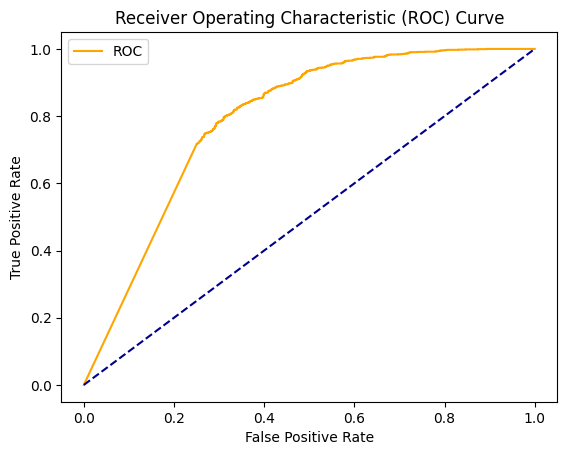

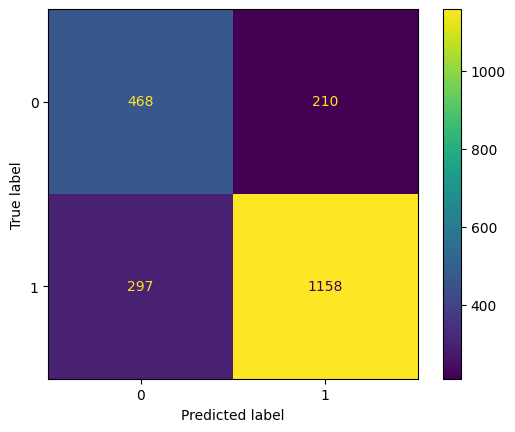

In [34]:
nb_model, accuracy_nb, roc_auc_nb, coh_kap_nb, tt_nb = run_model(nb_model, x_train, y_train, x_test, y_test)

C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_1988\1899461188.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Model', y='Time taken', data = data, palette='summer')


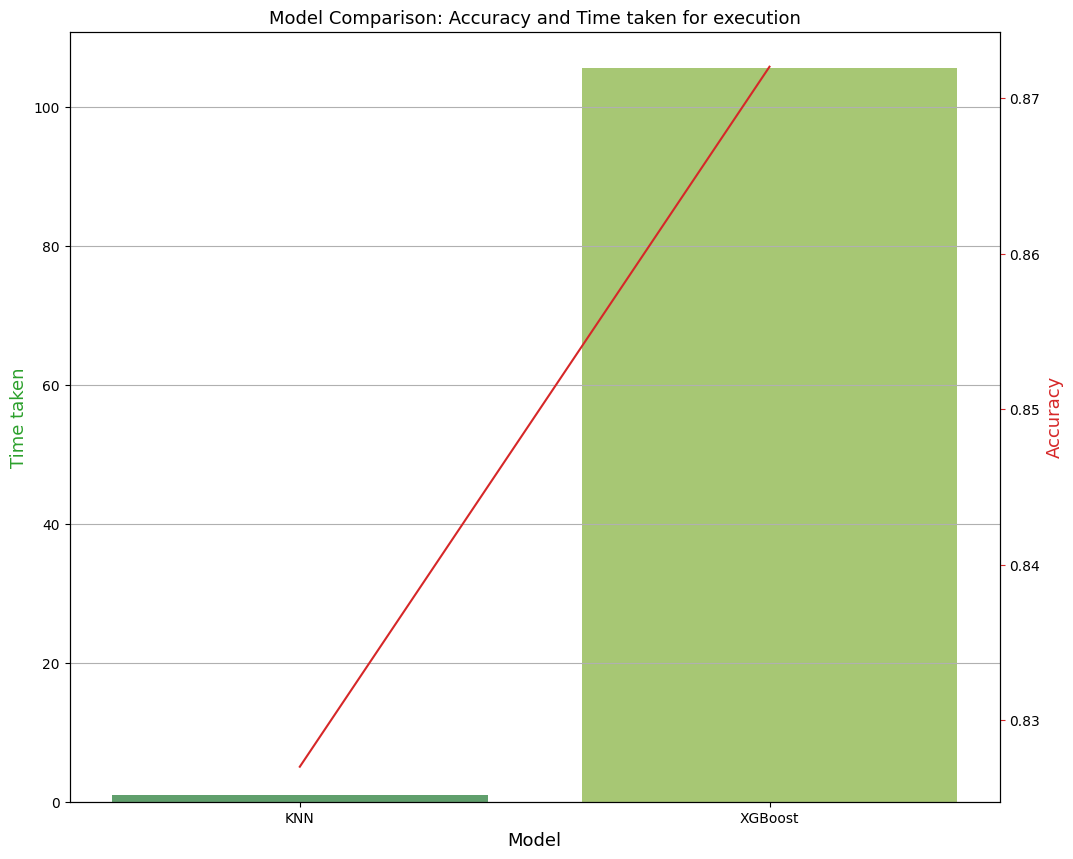

In [59]:
accuracy_scores = [accuracy_knn, accuracy_xgb,accuracy_nb]
roc_auc_scores = [roc_auc_knn, roc_auc_xgb]
coh_kap_scores = [coh_kap_knn, coh_kap_xgb]
tt = [tt_knn, tt_xgb]

model_data = {'Model': ['KNN','XGBoost','NaiveBayes',],
              'Accuracy': accuracy_scores,
              'ROC_AUC': roc_auc_scores,
              'Cohen_Kappa': coh_kap_scores,
              'Time taken': tt}
data = pd.DataFrame(model_data)

fig, ax1 = plt.subplots(figsize=(12,10))
ax1.set_title('Model Comparison: Accuracy and Time taken for execution', fontsize=13)
color = 'tab:green'
ax1.grid()
ax1.set_xlabel('Model', fontsize=13)
ax1.set_ylabel('Time taken', fontsize=13, color=color)
ax2 = sns.barplot(x='Model', y='Time taken', data = data, palette='summer')
ax1.tick_params(axis='y')
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Accuracy', fontsize=13, color=color)
ax2 = sns.lineplot(x='Model', y='Accuracy', data = data, sort=False, color=color)
ax2.tick_params(axis='y', color=color)

C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_1988\859903429.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x='Model', y='ROC_AUC', data = data, palette='winter')


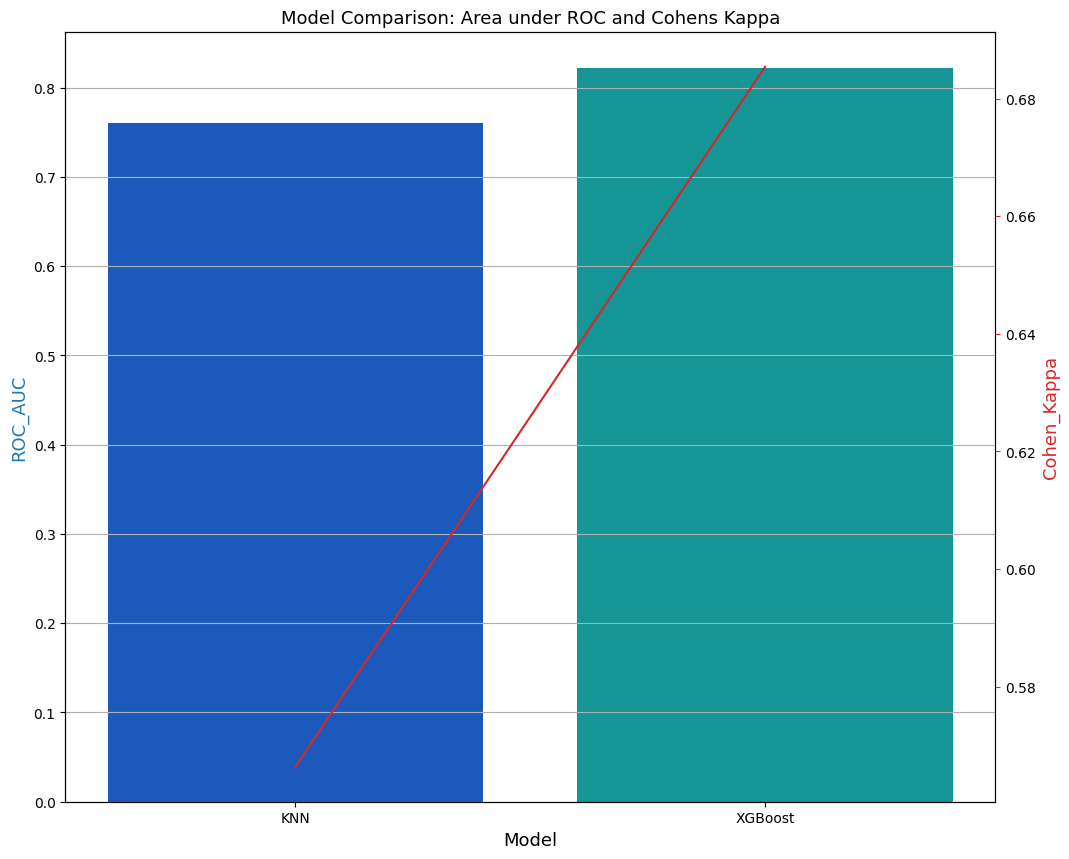

In [60]:
fig, ax3 = plt.subplots(figsize=(12,10))
ax3.set_title('Model Comparison: Area under ROC and Cohens Kappa', fontsize=13)
color = 'tab:blue'
ax3.grid()
ax3.set_xlabel('Model', fontsize=13)
ax3.set_ylabel('ROC_AUC', fontsize=13, color=color)
ax4 = sns.barplot(x='Model', y='ROC_AUC', data = data, palette='winter')
ax3.tick_params(axis='y')
ax4 = ax3.twinx()
color = 'tab:red'
ax4.set_ylabel('Cohen_Kappa', fontsize=13, color=color)
ax4 = sns.lineplot(x='Model', y='Cohen_Kappa', data = data, sort=False, color=color)
ax4.tick_params(axis='y', color=color)
plt.show()